# Hands-on practice: 从零摸清这个数据集

这个 notebook 的目标不是只给你一段能跑的代码，而是训练一种面对新数据集时的工作顺序：

1. 先确认项目路径和依赖。
2. 盘点原始数据有哪些文件、文件有多大、命名有什么规律。
3. 打开数据集自带的元数据和项目已经生成的 inventory。
4. 抽样打开一个原始 NWB 文件，理解它的层级结构。
5. 读取已经预处理出来的 interim 数据，理解每个表和数组分别代表什么。
6. 亲手做一个小型预处理：行为时间序列 + spike times -> head-direction tuning curve。

你可以按顺序运行，也可以每一节先猜一猜输出会是什么，再运行验证。

## 0. 面对新数据集时，先建立一个检查清单

以后拿到新的数据集，可以先问这几个问题：

- 数据在哪里？原始数据、中间结果、最终结果是否分开存放？
- 文件格式是什么？CSV、Parquet、NPZ、NWB/HDF5、图片，还是别的？
- 一个文件对应一个 subject、一个 session，还是一个 trial？
- 是否有 metadata/index 文件能告诉我们每个文件的含义？
- 时间单位是什么？秒、毫秒、采样点，还是帧号？
- 行为变量和神经信号是否在同一条时间轴上？如果不是，怎么对齐？

下面的代码会围绕这些问题一步步展开。

In [1]:
from pathlib import Path
import sys

# 让 notebook 无论从 notebooks/ 里启动，还是从项目根目录启动，都能找到项目根目录。
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw" / "dandi_000939" / "000939"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"

print("Python:", sys.executable)
print("Project root:", PROJECT_ROOT)
print("Raw exists:", RAW_DIR.exists(), RAW_DIR)
print("Interim exists:", INTERIM_DIR.exists(), INTERIM_DIR)
print("Processed exists:", PROCESSED_DIR.exists(), PROCESSED_DIR)

Python: e:\miniconda\envs\random\python.exe
Project root: d:\codefiles\python\diordered-circuits
Raw exists: True d:\codefiles\python\diordered-circuits\data\raw\dandi_000939\000939
Interim exists: True d:\codefiles\python\diordered-circuits\data\interim
Processed exists: True d:\codefiles\python\diordered-circuits\data\processed


In [2]:
# 依赖检查：如果这里报错，说明当前 Jupyter kernel 还没有装好本项目需要的包。
# 这个项目主要会用到 pandas/numpy/pynwb/pyarrow/matplotlib。
import importlib.util

required = ["numpy", "pandas", "matplotlib", "pynwb", "pyarrow"]
for name in required:
    status = "OK" if importlib.util.find_spec(name) is not None else "MISSING"
    print(f"{name:10s} {status}")

numpy      OK
pandas     OK
matplotlib OK
pynwb      OK
pyarrow    OK


如果有包显示 `MISSING`，先在你用于 Jupyter 的同一个环境里安装依赖，例如：

```bash
pip install numpy pandas matplotlib pynwb pyarrow tqdm
```

重点是“同一个环境”：上面第一格打印的 `Python:` 路径，就是这个 notebook 正在使用的解释器。

## 1. 先盘点文件，而不是马上读数据

一个新数据集最容易让人迷路的地方，是还没搞清楚“一个文件代表什么”就开始写读取代码。先看目录、后缀、大小和命名规律。

In [3]:
from collections import Counter

def human_size(n_bytes):
    units = ["B", "KB", "MB", "GB", "TB"]
    size = float(n_bytes)
    for unit in units:
        if size < 1024 or unit == units[-1]:
            return f"{size:.1f} {unit}"
        size /= 1024

all_raw_files = [p for p in RAW_DIR.rglob("*") if p.is_file()]
print("Raw file count:", len(all_raw_files))
print("Suffix counts:", Counter(p.suffix.lower() for p in all_raw_files))

for p in sorted(all_raw_files)[:8]:
    print(human_size(p.stat().st_size).rjust(10), p.relative_to(PROJECT_ROOT))

Raw file count: 32
Suffix counts: Counter({'.nwb': 31, '.yaml': 1})
    5.2 KB data\raw\dandi_000939\000939\dandiset.yaml
    1.5 GB data\raw\dandi_000939\000939\sub-A1808\sub-A1808_behavior+ecephys+ogen.nwb
    1.7 GB data\raw\dandi_000939\000939\sub-A1813\sub-A1813_behavior+ecephys+ogen.nwb
    1.5 GB data\raw\dandi_000939\000939\sub-A1815\sub-A1815_behavior+ecephys+ogen.nwb
    1.7 GB data\raw\dandi_000939\000939\sub-A1821\sub-A1821_behavior+ecephys+ogen.nwb
    1.4 GB data\raw\dandi_000939\000939\sub-A1824\sub-A1824_behavior+ecephys+ogen.nwb
    2.2 GB data\raw\dandi_000939\000939\sub-A3701\sub-A3701_behavior+ecephys.nwb
    1.9 GB data\raw\dandi_000939\000939\sub-A3702\sub-A3702_behavior+ecephys.nwb


In [4]:
nwb_files = sorted(RAW_DIR.rglob("*.nwb"))
print("NWB files:", len(nwb_files))

# 看看路径命名是否有规律：sub-A1808/sub-A1808_behavior+ecephys+ogen.nwb
for p in nwb_files[:5]:
    print("subject folder =", p.parent.name, "| file =", p.name)

NWB files: 31
subject folder = sub-A1808 | file = sub-A1808_behavior+ecephys+ogen.nwb
subject folder = sub-A1813 | file = sub-A1813_behavior+ecephys+ogen.nwb
subject folder = sub-A1815 | file = sub-A1815_behavior+ecephys+ogen.nwb
subject folder = sub-A1821 | file = sub-A1821_behavior+ecephys+ogen.nwb
subject folder = sub-A1824 | file = sub-A1824_behavior+ecephys+ogen.nwb


观察点：

- `sub-A1808` 这样的目录通常表示 subject。
- 文件名里有 `behavior+ecephys+ogen`，说明文件里可能同时包含行为、电生理和光遗传相关信息。
- `.nwb` 是 Neurodata Without Borders 格式，本质上是一个有神经科学语义的 HDF5 容器。不要把它当普通 CSV 读。

## 2. 读项目已经生成的 inventory/index

真实项目里，最省时间的办法通常是先找 index/inventory/report。它们是原始数据和分析代码之间的地图。

In [5]:
import pandas as pd

inventory_path = REPORTS_DIR / "nwb_inventory.csv"
inventory = pd.read_csv(inventory_path)
print(inventory.shape)
inventory.head()

(31, 11)


,file,identifier,session_description,session_start_time,subject,acquisition_keys,processing_keys,interval_keys,has_units,unit_columns,n_units
0,data\raw\dandi_000939\000939\sub-A1808\sub-A18...,A1808,Open field and sleep recording,2019-08-07 00:00:00-04:00,"{'subject_id': 'A1808', 'species': 'Mus muscul...",[],"['behavior', 'ecephys', 'ogen']","['epochs', 'nrem', 'rem']",True,"['electrode_index', 'trough_to_peak', 'is_exci...",101
1,data\raw\dandi_000939\000939\sub-A1813\sub-A18...,A1813,Open field and sleep recording,2019-04-08 00:00:00-04:00,"{'subject_id': 'A1813', 'species': 'Mus muscul...",[],"['behavior', 'ecephys', 'ogen']","['epochs', 'nrem', 'rem']",True,"['electrode_index', 'trough_to_peak', 'is_exci...",70
2,data\raw\dandi_000939\000939\sub-A1815\sub-A18...,A1815,Open field and sleep recording,2019-05-23 00:00:00-04:00,"{'subject_id': 'A1815', 'species': 'Mus muscul...",[],"['behavior', 'ecephys', 'ogen']","['epochs', 'nrem', 'rem']",True,"['electrode_index', 'trough_to_peak', 'is_exci...",65
3,data\raw\dandi_000939\000939\sub-A1821\sub-A18...,A1821,Open field and sleep recording,2019-09-10 00:00:00-04:00,"{'subject_id': 'A1821', 'species': 'Mus muscul...",[],"['behavior', 'ecephys', 'ogen']","['epochs', 'nrem', 'rem']",True,"['electrode_index', 'trough_to_peak', 'is_exci...",74
4,data\raw\dandi_000939\000939\sub-A1824\sub-A18...,A1824,Open field and sleep recording,2019-08-27 00:00:00-04:00,"{'subject_id': 'A1824', 'species': 'Mus muscul...",[],"['behavior', 'ecephys', 'ogen']","['epochs', 'nrem', 'rem']",True,"['electrode_index', 'trough_to_peak', 'is_exci...",70


In [6]:
cols = ["identifier", "session_description", "subject", "processing_keys", "interval_keys", "unit_columns", "n_units"]
inventory[cols].head(3)

,identifier,session_description,subject,processing_keys,interval_keys,unit_columns,n_units
0,A1808,Open field and sleep recording,"{'subject_id': 'A1808', 'species': 'Mus muscul...","['behavior', 'ecephys', 'ogen']","['epochs', 'nrem', 'rem']","['electrode_index', 'trough_to_peak', 'is_exci...",101
1,A1813,Open field and sleep recording,"{'subject_id': 'A1813', 'species': 'Mus muscul...","['behavior', 'ecephys', 'ogen']","['epochs', 'nrem', 'rem']","['electrode_index', 'trough_to_peak', 'is_exci...",70
2,A1815,Open field and sleep recording,"{'subject_id': 'A1815', 'species': 'Mus muscul...","['behavior', 'ecephys', 'ogen']","['epochs', 'nrem', 'rem']","['electrode_index', 'trough_to_peak', 'is_exci...",65


从 inventory 可以先建立初步理解：

- `processing_keys` 里有 `behavior`, `ecephys`, `ogen`。
- `interval_keys` 里有 `epochs`, `nrem`, `rem`。
- `unit_columns` 里有 `spike_times`, `is_excitatory`, `is_head_direction` 等。
- 每个 NWB 文件有几十到上百个 units。

这一步很重要：你还没打开大文件，就已经知道应该去哪几层找东西了。

In [7]:
session_index = pd.read_csv(INTERIM_DIR / "session_index.csv")
print(session_index.shape)
session_index.head()

(31, 14)


,subject_id,session_id,file,wake_square_start_s,wake_square_stop_s,wake_square_duration_s,n_behavior_samples,n_units,n_included_initial,n_included_qc,behavior_path,units_path,spikes_path,status
0,A1808,sub-A1808_behavior+ecephys+ogen,data\raw\dandi_000939\000939\sub-A1808\sub-A18...,2735.856,3648.348,912.492,90527,101,29,29,data\interim\A1808_behavior_wake_square.parquet,data\interim\A1808_units_meta.parquet,data\interim\A1808_spikes_wake_square.npz,ok
1,A1813,sub-A1813_behavior+ecephys+ogen,data\raw\dandi_000939\000939\sub-A1813\sub-A18...,3966.804,5008.896,1042.092,103017,70,30,30,data\interim\A1813_behavior_wake_square.parquet,data\interim\A1813_units_meta.parquet,data\interim\A1813_spikes_wake_square.npz,ok
2,A1815,sub-A1815_behavior+ecephys+ogen,data\raw\dandi_000939\000939\sub-A1815\sub-A18...,3560.976,4468.392,907.416,88685,65,33,33,data\interim\A1815_behavior_wake_square.parquet,data\interim\A1815_units_meta.parquet,data\interim\A1815_spikes_wake_square.npz,ok
3,A1821,sub-A1821_behavior+ecephys+ogen,data\raw\dandi_000939\000939\sub-A1821\sub-A18...,3042.648,5749.632,2706.984,267509,74,37,37,data\interim\A1821_behavior_wake_square.parquet,data\interim\A1821_units_meta.parquet,data\interim\A1821_spikes_wake_square.npz,ok
4,A1824,sub-A1824_behavior+ecephys+ogen,data\raw\dandi_000939\000939\sub-A1824\sub-A18...,2762.496,3970.260,1207.764,119589,70,39,39,data\interim\A1824_behavior_wake_square.parquet,data\interim\A1824_units_meta.parquet,data\interim\A1824_spikes_wake_square.npz,ok


In [8]:
session_index[["subject_id", "wake_square_duration_s", "n_behavior_samples", "n_units", "n_included_qc", "status"]].describe(include="all")

,subject_id,wake_square_duration_s,n_behavior_samples,n_units,n_included_qc,status
count,31,31.000000,31.000000,31.000000,31.000000,31
unique,31,NaN,NaN,NaN,NaN,1
top,A1808,NaN,NaN,NaN,NaN,ok
freq,1,NaN,NaN,NaN,NaN,31
mean,NaN,1868.960839,185066.258065,86.806452,49.451613,NaN
std,NaN,558.678241,55768.951547,33.474786,24.639858,NaN
min,NaN,907.416000,88685.000000,42.000000,21.000000,NaN
25%,NaN,1514.538000,144889.000000,62.500000,30.000000,NaN
50%,NaN,1821.744000,180472.000000,77.000000,39.000000,NaN
75%,NaN,2408.472000,239993.500000,102.500000,65.500000,NaN


`session_index.csv` 是预处理后的索引表。它告诉我们每个 subject/session 对应哪些输出文件：

- `behavior_path`: 行为时间序列。
- `units_path`: 神经元 metadata 和 QC 标记。
- `spikes_path`: 每个 unit 在 wake_square 阶段的 spike times。

这也是以后组织自己项目时很推荐的做法：让每一步输出一个 index 文件，记录输入、输出、数量和状态。

## 3. 抽样打开一个原始 NWB 文件

下面只打开第一个文件做结构探索。原始文件很大，所以先抽样，不要一上来循环全量读取。

In [9]:
from pynwb import NWBHDF5IO

one_nwb_path = nwb_files[0]
print(one_nwb_path.relative_to(PROJECT_ROOT))

with NWBHDF5IO(str(one_nwb_path), "r", load_namespaces=True) as io:
    nwb = io.read()
    print("identifier:", nwb.identifier)
    print("session_description:", nwb.session_description)
    print("subject_id:", nwb.subject.subject_id)
    print("processing keys:", list(nwb.processing.keys()))
    print("interval keys:", list(nwb.intervals.keys()))
    print("unit columns:", list(nwb.units.colnames))
    print("n units:", len(nwb.units.id[:]))

data\raw\dandi_000939\000939\sub-A1808\sub-A1808_behavior+ecephys+ogen.nwb
identifier: A1808
session_description: Open field and sleep recording
subject_id: A1808
processing keys: ['behavior', 'ecephys', 'ogen']
interval keys: ['epochs', 'nrem', 'rem']
unit columns: ['electrode_index', 'trough_to_peak', 'is_excitatory', 'is_fast_spiking', 'is_head_direction', 'spike_times', 'electrode_group', 'waveform_mean']
n units: 101


In [10]:
# 看 behavior processing module 下面有哪些 data interfaces。
with NWBHDF5IO(str(one_nwb_path), "r", load_namespaces=True) as io:
    nwb = io.read()
    behavior_module = nwb.processing["behavior"]
    print("behavior data interfaces:", list(behavior_module.data_interfaces.keys()))
    
    compass = behavior_module["CompassDirection"]
    position = behavior_module["Position"]
    print("CompassDirection spatial series:", list(compass.spatial_series.keys()))
    print("Position spatial series:", list(position.spatial_series.keys()))

behavior data interfaces: ['CompassDirection', 'Position', 'accelerometer']
CompassDirection spatial series: ['head-direction']
Position spatial series: ['position']


In [11]:
# 查看 epochs，找到 wake_square 这段行为。
with NWBHDF5IO(str(one_nwb_path), "r", load_namespaces=True) as io:
    nwb = io.read()
    epochs = nwb.intervals["epochs"].to_dataframe()

epochs.head(10)

,start_time,stop_time,tags
id,,,
0,0.00005,2735.856,[home_cage]
1,2735.85600,3648.348,[wake_square]
2,3648.34800,7489.656,[home_cage]
3,7489.65600,10198.690,[wake_opto]


In [12]:
wake_rows = epochs[epochs["tags"].apply(lambda tags: "wake_square" in [str(x) for x in tags])]
wake_rows

,start_time,stop_time,tags
id,,,
1,2735.856,3648.348,[wake_square]


到这里，你已经能回答一个很实际的问题：为什么后面的代码只分析 `wake_square`？因为这个行为阶段在 NWB 的 `intervals/epochs` 里有明确的起止时间。预处理就是把全文件中的行为和 spike times 裁剪到这段时间。

## 4. 读取已经提取好的 interim 数据

原始 NWB 适合保存完整信息，但每次分析都直接读 NWB 会比较慢。项目里的 `data/interim` 是更适合日常分析的中间层。

In [13]:
row = session_index.iloc[0]
subject_id = row["subject_id"]
print(subject_id)
print(row[["behavior_path", "units_path", "spikes_path"]])

A1808
behavior_path    data\interim\A1808_behavior_wake_square.parquet
units_path                 data\interim\A1808_units_meta.parquet
spikes_path            data\interim\A1808_spikes_wake_square.npz
Name: 0, dtype: object


In [16]:
behavior = pd.read_parquet(PROJECT_ROOT / row["behavior_path"])
units = pd.read_parquet(PROJECT_ROOT / row["units_path"])

print("behavior shape:", behavior.shape)
display(behavior.head())
display(behavior.dtypes)

print("units shape:", units.shape)
display(units.head())
display(units.dtypes)

behavior shape: (90527, 6)


,time_s,head_direction_rad,x_cm,y_cm,subject_id,session_id
0,2739.046,2.469564,20.96976,34.93536,A1808,sub-A1808_behavior+ecephys+ogen
1,2739.816,4.025174,37.37904,-6.23280,A1808,sub-A1808_behavior+ecephys+ogen
2,2739.826,4.026701,37.41936,-6.31888,A1808,sub-A1808_behavior+ecephys+ogen
3,2739.836,4.023930,37.46912,-6.39728,A1808,sub-A1808_behavior+ecephys+ogen
4,2739.846,4.025883,37.52752,-6.46992,A1808,sub-A1808_behavior+ecephys+ogen


time_s                float64
head_direction_rad    float64
x_cm                  float64
y_cm                  float64
subject_id             object
session_id             object
dtype: object

units shape: (101, 18)


,unit_id,electrode_index,trough_to_peak,is_excitatory,is_fast_spiking,is_head_direction,electrode_group,included_initial,n_spikes_total,n_spikes_wake_square,mean_rate_wake_square_hz,included_qc,exclude_reason,subject_id,session_id,wake_square_start_s,wake_square_stop_s,wake_square_duration_s
0,0,24,NaN,False,False,False,shank0,False,12884,208,0.227947,False,not_excitatory;not_head_direction;,A1808,sub-A1808_behavior+ecephys+ogen,2735.856,3648.348,912.492
1,1,28,0.290,False,False,False,shank0,False,62039,7751,8.494321,False,not_excitatory;not_head_direction;,A1808,sub-A1808_behavior+ecephys+ogen,2735.856,3648.348,912.492
2,2,62,0.545,True,False,True,shank0,True,15095,1261,1.381930,True,,A1808,sub-A1808_behavior+ecephys+ogen,2735.856,3648.348,912.492
3,3,18,0.235,False,True,False,shank0,False,195463,16236,17.793033,False,not_excitatory;not_head_direction;,A1808,sub-A1808_behavior+ecephys+ogen,2735.856,3648.348,912.492
4,4,54,0.525,True,False,True,shank0,True,13002,1454,1.593439,True,,A1808,sub-A1808_behavior+ecephys+ogen,2735.856,3648.348,912.492


unit_id                       int64
electrode_index               int64
trough_to_peak              float64
is_excitatory                  bool
is_fast_spiking                bool
is_head_direction              bool
electrode_group              object
included_initial               bool
n_spikes_total                int64
n_spikes_wake_square          int64
mean_rate_wake_square_hz    float64
included_qc                    bool
exclude_reason               object
subject_id                   object
session_id                   object
wake_square_start_s         float64
wake_square_stop_s          float64
wake_square_duration_s      float64
dtype: object

理解这两个表：

- `behavior` 每一行是一个行为采样点，包含 `time_s`, `head_direction_rad`, `x_cm`, `y_cm`。
- `units` 每一行是一个神经元，包含 unit 的属性、spike 数量、平均 firing rate、是否通过 QC。
- `head_direction_rad` 的单位是弧度，范围是 `[0, 2π)`。
- `time_s` 的单位是秒，并且已经被裁剪到 `wake_square` 阶段。

In [17]:
import numpy as np

spikes = np.load(PROJECT_ROOT / row["spikes_path"])
print("number of spike arrays:", len(spikes.files))
print("first 10 keys:", spikes.files[:10])

first_key = spikes.files[0]
first_spike_times = spikes[first_key]
print(first_key, first_spike_times.shape)
print(first_spike_times[:10])
print("time range:", first_spike_times.min(), first_spike_times.max())

number of spike arrays: 101
first 10 keys: ['unit_0', 'unit_1', 'unit_2', 'unit_3', 'unit_4', 'unit_5', 'unit_6', 'unit_7', 'unit_8', 'unit_9']
unit_0 (208,)
[2760.07085 2760.25035 2760.30355 2760.4452  2804.45695 2814.33035
 2874.3478  3164.6419  3164.7164  3164.726  ]
time range: 2760.07085 3641.6599


`spikes_wake_square.npz` 不是表格，而是很多个数组的压缩包。键名类似 `unit_0`, `unit_1`，每个数组是这个 unit 在 wake_square 阶段的 spike time，单位同样是秒。

## 5. 做基本质量检查

面对新数据集时，不要假设数据已经干净。先检查范围、缺失值、时间是否单调、采样间隔是否稳定。

In [18]:
# 如果你是从第 5 节开始跳着运行，这个 cell 会恢复前面几节创建的上下文变量。
from pathlib import Path
import pandas as pd
import numpy as np

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent
    DATA_DIR = PROJECT_ROOT / "data"
    RAW_DIR = DATA_DIR / "raw" / "dandi_000939" / "000939"
    INTERIM_DIR = DATA_DIR / "interim"
    PROCESSED_DIR = DATA_DIR / "processed"
    REPORTS_DIR = PROJECT_ROOT / "reports"

if "session_index" not in globals():
    session_index = pd.read_csv(INTERIM_DIR / "session_index.csv")

if "row" not in globals():
    row = session_index.iloc[0]
    subject_id = row["subject_id"]

if "behavior" not in globals():
    behavior = pd.read_parquet(PROJECT_ROOT / row["behavior_path"])

if "units" not in globals():
    units = pd.read_parquet(PROJECT_ROOT / row["units_path"])

if "spikes" not in globals():
    spikes = np.load(PROJECT_ROOT / row["spikes_path"])

print("Loaded subject:", subject_id)
print("behavior:", behavior.shape)
print("units:", units.shape)
print("spike arrays:", len(spikes.files))

Loaded subject: A1808
behavior: (90527, 6)
units: (101, 18)
spike arrays: 101


In [19]:
check = {
    "n_rows": len(behavior),
    "time_min": behavior["time_s"].min(),
    "time_max": behavior["time_s"].max(),
    "time_monotonic": behavior["time_s"].is_monotonic_increasing,
    "missing_values": int(behavior.isna().sum().sum()),
    "hd_min": behavior["head_direction_rad"].min(),
    "hd_max": behavior["head_direction_rad"].max(),
}
check

{'n_rows': 90527,
 'time_min': np.float64(2739.046),
 'time_max': np.float64(3645.566),
 'time_monotonic': True,
 'missing_values': 0,
 'hd_min': np.float64(0.0001237612972589179),
 'hd_max': np.float64(6.283037844311085)}

In [20]:
dt = behavior["time_s"].diff().dropna()
dt.describe(percentiles=[0.01, 0.5, 0.99])

count    90526.000000
mean         0.010014
std          0.002699
min          0.010000
1%           0.010000
50%          0.010000
99%          0.010000
max          0.770000
Name: time_s, dtype: float64

In [21]:
units[["unit_id", "is_excitatory", "is_head_direction", "included_initial", "included_qc", "n_spikes_wake_square", "mean_rate_wake_square_hz"]].head(10)

,unit_id,is_excitatory,is_head_direction,included_initial,included_qc,n_spikes_wake_square,mean_rate_wake_square_hz
0,0,False,False,False,False,208,0.227947
1,1,False,False,False,False,7751,8.494321
2,2,True,True,True,True,1261,1.381930
3,3,False,False,False,False,16236,17.793033
4,4,True,True,True,True,1454,1.593439
5,5,True,True,True,True,1811,1.984675
6,6,True,True,True,True,1409,1.544123
7,7,True,True,True,True,2105,2.306870
8,8,True,True,True,True,7076,7.754589
9,9,False,False,False,False,11,0.012055


经验规则：

- 时间列应该单调递增。
- 角度数据要确认单位和范围，这里是弧度 `[0, 2π)`。
- spike times 要落在行为时间范围内。
- QC 标记不要盲目信任，但要先理解它如何生成。这个项目里 `included_qc = is_excitatory & is_head_direction & n_spikes_wake_square >= 50`。

## 6. 可视化行为变量

先画图不是为了好看，而是为了发现单位、范围、断点、异常值。

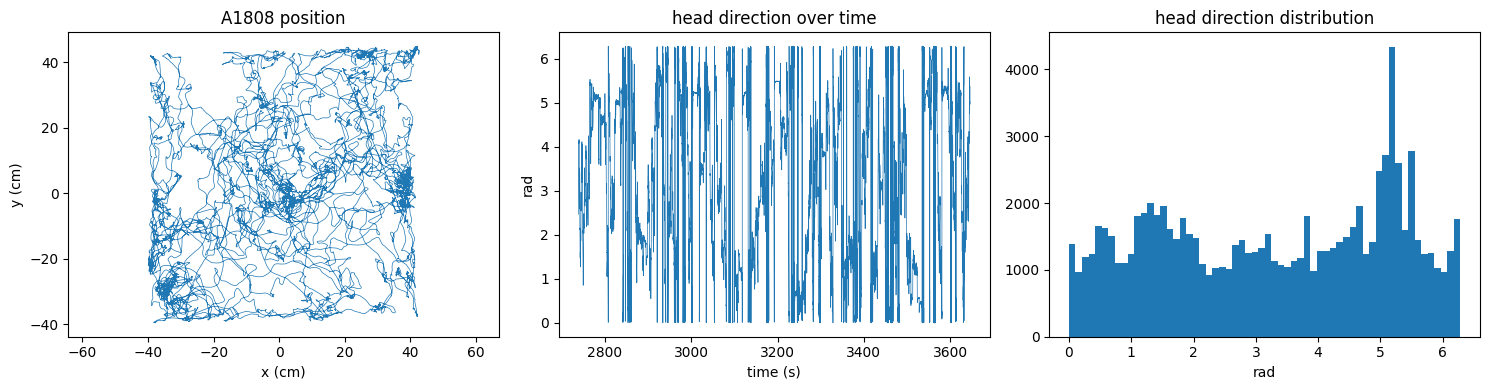

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(behavior["x_cm"], behavior["y_cm"], lw=0.5)
axes[0].set_title(f"{subject_id} position")
axes[0].set_xlabel("x (cm)")
axes[0].set_ylabel("y (cm)")
axes[0].axis("equal")

axes[1].plot(behavior["time_s"], behavior["head_direction_rad"], lw=0.5)
axes[1].set_title("head direction over time")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("rad")

axes[2].hist(behavior["head_direction_rad"], bins=60)
axes[2].set_title("head direction distribution")
axes[2].set_xlabel("rad")

plt.tight_layout()

## 7. 亲手计算 occupancy 和一个 unit 的 tuning curve

核心思想：

- 先把 head direction 分箱。
- 统计动物在每个方向 bin 里停留了多少秒，这叫 occupancy。
- 把 spike time 插值到行为时间轴上，得到每个 spike 发生时的 head direction。
- 每个 bin 的 firing rate = spike count / occupancy seconds。

In [23]:
def estimate_dt_seconds(time_s):
    diffs = np.diff(time_s)
    good = diffs[np.isfinite(diffs) & (diffs > 0)]
    typical = float(np.median(good))
    dt = np.r_[diffs, typical]
    dt[~np.isfinite(dt) | (dt <= 0) | (dt > 5 * typical)] = typical
    return dt

def bin_angles_rad(angles_rad, n_bins=60):
    edges = np.linspace(0, 2 * np.pi, n_bins + 1)
    idx = np.searchsorted(edges, angles_rad % (2 * np.pi), side="right") - 1
    idx = np.clip(idx, 0, n_bins - 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return idx, edges, centers

def occupancy_by_head_direction(behavior, n_bins=60):
    time_s = behavior["time_s"].to_numpy(float)
    hd = behavior["head_direction_rad"].to_numpy(float)
    dt = estimate_dt_seconds(time_s)
    hd_bin, edges, centers = bin_angles_rad(hd, n_bins=n_bins)
    occupancy_s = np.bincount(hd_bin, weights=dt, minlength=n_bins)
    return occupancy_s, edges, centers

occupancy_s, edges, centers = occupancy_by_head_direction(behavior, n_bins=60)
print("Total occupancy seconds:", occupancy_s.sum())
print("Behavior duration seconds:", behavior["time_s"].iloc[-1] - behavior["time_s"].iloc[0])

Total occupancy seconds: 905.3700000000013
Behavior duration seconds: 906.52


In [24]:
qc_units = units.loc[units["included_qc"], "unit_id"].astype(int).to_list()
unit_id = qc_units[0]
unit_spikes = spikes[f"unit_{unit_id}"]
print("chosen unit:", unit_id)
print("n spikes:", len(unit_spikes))

time_s = behavior["time_s"].to_numpy(float)
hd = behavior["head_direction_rad"].to_numpy(float)

keep = (unit_spikes >= time_s[0]) & (unit_spikes <= time_s[-1])
spike_hd = np.interp(unit_spikes[keep], time_s, hd) % (2 * np.pi)
spike_bins, _, _ = bin_angles_rad(spike_hd, n_bins=60)
spike_counts = np.bincount(spike_bins, minlength=60)

rate_hz = np.full(60, np.nan)
valid = occupancy_s >= 0.05
rate_hz[valid] = spike_counts[valid] / occupancy_s[valid]

print("rate shape:", rate_hz.shape)
print("max rate:", np.nanmax(rate_hz))

chosen unit: 2
n spikes: 1261
rate shape: (60,)
max rate: 13.975155279500028


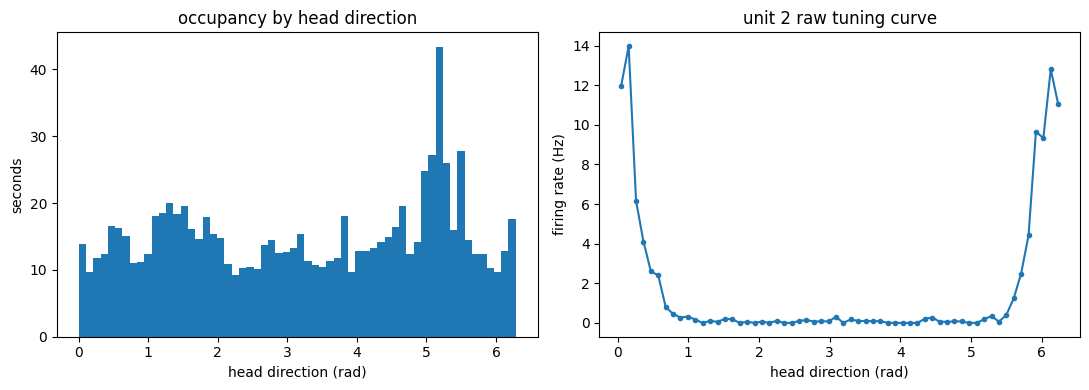

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), subplot_kw={"projection": None})

axes[0].bar(centers, occupancy_s, width=np.diff(edges), align="center")
axes[0].set_title("occupancy by head direction")
axes[0].set_xlabel("head direction (rad)")
axes[0].set_ylabel("seconds")

axes[1].plot(centers, rate_hz, marker="o", ms=3)
axes[1].set_title(f"unit {unit_id} raw tuning curve")
axes[1].set_xlabel("head direction (rad)")
axes[1].set_ylabel("firing rate (Hz)")

plt.tight_layout()

你刚刚手写了一遍 `src/compute_hd_tuning.py` 的核心逻辑。项目脚本做的是批量版本，并且还加入了 100 bins、平滑、unit mean normalization、split-half reliability 等步骤。

## 8. 读取 processed 结果，连接到项目最终产物

现在再看 `data/processed`，会更容易理解每个数组的含义。

In [26]:
tuning_index = pd.read_csv(PROCESSED_DIR / "hd_tuning_index.csv")
tuning_index.head()

,subject_id,session_id,n_units,n_included_qc,total_occupancy_s,median_chosen_sigma_bins,median_split_half_r,tuning_path
0,A1808,sub-A1808_behavior+ecephys+ogen,101,29,905.37,4.0,0.406191,data\processed\A1808_hd_tuning_100bins.npz
1,A1813,sub-A1813_behavior+ecephys+ogen,70,30,1030.24,3.0,0.654561,data\processed\A1813_hd_tuning_100bins.npz
2,A1815,sub-A1815_behavior+ecephys+ogen,65,33,886.97,2.0,0.762679,data\processed\A1815_hd_tuning_100bins.npz
3,A1821,sub-A1821_behavior+ecephys+ogen,74,37,2675.89,2.0,0.908321,data\processed\A1821_hd_tuning_100bins.npz
4,A1824,sub-A1824_behavior+ecephys+ogen,70,39,1196.10,2.0,0.883776,data\processed\A1824_hd_tuning_100bins.npz


In [27]:
tuning_path = PROJECT_ROOT / tuning_index.loc[tuning_index["subject_id"].eq(subject_id), "tuning_path"].iloc[0]
tuning = np.load(tuning_path)

for key in tuning.files:
    arr = tuning[key]
    print(f"{key:22s} shape={arr.shape!s:14s} dtype={arr.dtype}")

unit_ids               shape=(101,)         dtype=int64
bin_edges_rad          shape=(101,)         dtype=float64
bin_centers_rad        shape=(100,)         dtype=float64
occupancy_s            shape=(100,)         dtype=float64
spike_counts           shape=(101, 100)     dtype=float64
raw_rate_hz            shape=(101, 100)     dtype=float64
smoothed_rate_hz       shape=(101, 100)     dtype=float64
normalized_rate        shape=(101, 100)     dtype=float64
unit_mean_rate_hz      shape=(101,)         dtype=float64
chosen_sigma_bins      shape=(101,)         dtype=float64
cv_sigma_candidates    shape=(7,)           dtype=float64
cv_mse                 shape=(101, 7)       dtype=float64
split_half_r           shape=(101,)         dtype=float64
included_qc            shape=(101,)         dtype=bool


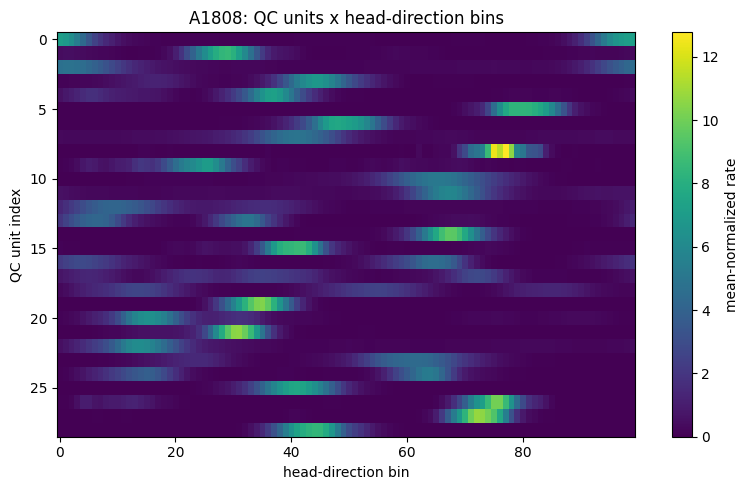

In [28]:
unit_ids = tuning["unit_ids"]
included_qc = tuning["included_qc"].astype(bool)
centers100 = tuning["bin_centers_rad"]
normalized = tuning["normalized_rate"]

qc_indices = np.flatnonzero(included_qc)
plt.figure(figsize=(8, 5))
plt.imshow(normalized[qc_indices], aspect="auto", interpolation="nearest", cmap="viridis")
plt.colorbar(label="mean-normalized rate")
plt.title(f"{subject_id}: QC units x head-direction bins")
plt.xlabel("head-direction bin")
plt.ylabel("QC unit index")
plt.tight_layout()

## 9. 给未来自己的模板

以后遇到新数据集，可以按这个顺序写最小探索 notebook：

1. 打印 `Path.cwd()`、数据目录是否存在、Python 环境。
2. 递归列文件，统计后缀、大小、命名规律。
3. 找 metadata/index/inventory；没有就自己生成一个。
4. 抽样打开一个文件，打印顶层 keys、shape、dtype、时间范围。
5. 明确观测单位：一行是 sample、trial、unit、session，还是 subject？
6. 做质量检查：缺失、范围、时间单调、重复 ID、异常大小。
7. 先处理一个小样本，确认逻辑后再批量处理。
8. 每个批处理步骤都保存 index，记录输入、输出、状态和关键数量。

这套流程比记住某个数据集的字段名更重要。字段名会变，但探索顺序可以一直复用。